In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import numpy as np
from scipy import stats
import smarts_cerebellum.globals as gl

# using observed values, since each subject should have their own dot
df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'WMPMII_DTI_flip.tsv'), sep = '\t')
df = df[(df.metric == 'FaMap') & (df.isPatient == 1)]

/localscratch/tmp/ipykernel_46374/1508099881.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(os.path.join(gl.baseDir, 'DTI', 'WMPMII_DTI_flip.tsv'), sep = '\t')


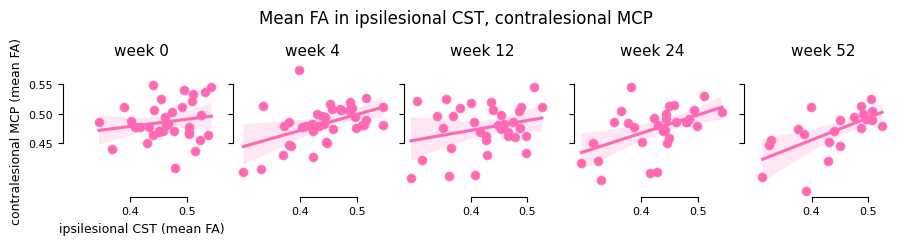

In [3]:
fig, axs = plt.subplots(1, 5, figsize = (9, 2), sharey = True, sharex = True, constrained_layout = True)
for i, week in enumerate(gl.weeks):
    df_week = df[df.Week == week]
    df_week = df_week.pivot_table(index = 'subj_id',columns = 'regionname', values = 'mean')
    # ipsilesional CST = CST_R; contralesional MCP = MCP_L
    ax = axs[i]
    sns.scatterplot(x = df_week['CST_R'], y =  df_week['MCP_L'], ax = ax, color = 'hotpink')
    sns.regplot(x = df_week['CST_R'], y =  df_week['MCP_L'], ax = ax, color = 'hotpink')
    sns.despine(trim = True)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_title(f'week {week}')

axs[0].set_xlabel("ipsilesional CST (mean FA)")
axs[0].set_ylabel("contralesional MCP (mean FA)")

fig.suptitle(f"Mean FA in ipsilesional CST, contralesional MCP", y = 1.15)
plt.show()



In [4]:
from scipy import stats
print("---pearson R correlation--- \n")
for week in gl.weeks:
    corr, p_val = stats.pearsonr(df[(df.Week == week) & (df.regionname == 'CST_R')]['mean'], df[(df.Week == week) & (df.regionname == 'MCP_L')]['mean'])
    print(f'*week {week}*: correlation = {corr}, p-value = {p_val} \n')

---pearson R correlation--- 

*week 0*: correlation = 0.1815887856851522, p-value = 0.29649032492251215 

*week 4*: correlation = 0.4734793201330991, p-value = 0.0030773727877756347 

*week 12*: correlation = 0.268288894250145, p-value = 0.12499364112338605 

*week 24*: correlation = 0.4978165500835892, p-value = 0.005121144308844547 

*week 52*: correlation = 0.6242122501019803, p-value = 0.0024912167854128963 

